In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

ModuleNotFoundError: No module named 'seaborn'

In [30]:
data = pd.read_csv('data/raw/life_expectancy_data.csv', delimiter=',')

In [31]:
print(data.head())

       Country  Year      Status  Life expectancy   Adult Mortality  \
0  Afghanistan  2015  Developing              65.0            263.0   
1  Afghanistan  2014  Developing              59.9            271.0   
2  Afghanistan  2013  Developing              59.9            268.0   
3  Afghanistan  2012  Developing              59.5            272.0   
4  Afghanistan  2011  Developing              59.2            275.0   

   infant deaths  Alcohol  percentage expenditure  Hepatitis B  Measles   ...  \
0             62     0.01               71.279624         65.0      1154  ...   
1             64     0.01               73.523582         62.0       492  ...   
2             66     0.01               73.219243         64.0       430  ...   
3             69     0.01               78.184215         67.0      2787  ...   
4             71     0.01                7.097109         68.0      3013  ...   

   Polio  Total expenditure  Diphtheria    HIV/AIDS         GDP  Population  \
0    6.

In [20]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2732 entries, 0 to 2731
Data columns (total 22 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Country                          2732 non-null   object 
 1   Year                             2732 non-null   int64  
 2   Status                           2732 non-null   object 
 3   Life expectancy                  2724 non-null   float64
 4   Adult Mortality                  2724 non-null   float64
 5   infant deaths                    2732 non-null   int64  
 6   Alcohol                          2547 non-null   float64
 7   percentage expenditure           2732 non-null   float64
 8   Hepatitis B                      2207 non-null   float64
 9   Measles                          2732 non-null   int64  
 10   BMI                             2699 non-null   float64
 11  under-five deaths                2732 non-null   int64  
 12  Polio               

In [21]:
print(data.isnull().sum())

Country                              0
Year                                 0
Status                               0
Life expectancy                      8
Adult Mortality                      8
infant deaths                        0
Alcohol                            185
percentage expenditure               0
Hepatitis B                        525
Measles                              0
 BMI                                33
under-five deaths                    0
Polio                               18
Total expenditure                  215
Diphtheria                          18
 HIV/AIDS                            0
GDP                                415
Population                         604
 thinness  1-19 years               33
 thinness 5-9 years                 33
Income composition of resources    155
Schooling                          151
dtype: int64


In [22]:
data_cleaned = data.dropna()

In [23]:
features = ['Adult Mortality', 'infant deaths', 'Alcohol', 'percentage expenditure',
                 'Hepatitis B', 'Measles ', ' BMI ', 'under-five deaths ',
                 'Polio', 'Total expenditure', 'Diphtheria ',
                 ' HIV/AIDS', 'GDP', 'Population',
                 ' thinness  1-19 years', ' thinness 5-9 years',
                 'Income composition of resources', 'Schooling']

In [24]:
X = data_cleaned[features]
y = data_cleaned['Life expectancy ']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [25]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [26]:
y_pred = model.predict(X_test)

# Оценка модели
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'Mean Squared Error: {mse}')
print(f'R^2 Score: {r2}')

Mean Squared Error: 12.667556542952983
R^2 Score: 0.8288868505589373


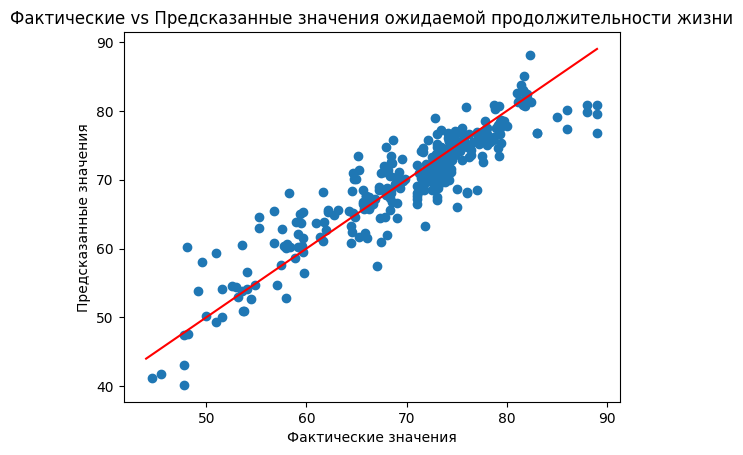

In [27]:
plt.scatter(y_test, y_pred)
plt.xlabel('Фактические значения')
plt.ylabel('Предсказанные значения')
plt.title('Фактические vs Предсказанные значения ожидаемой продолжительности жизни')
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red')  # Линия y=x
plt.show()

In [28]:
residuals = y_test - y_pred
plt.figure(figsize=(10, 6))
sns.histplot(residuals, bins=30, kde=True)
plt.title('Распределение остатков')
plt.xlabel('Остатки')
plt.ylabel('Частота')
plt.show()

NameError: name 'sns' is not defined

<Figure size 1000x600 with 0 Axes>